In [22]:
print (table)

+--------------------+---------+----------------------+
|       Model        | ROC-AUC | Precision-Recall AUC |
+--------------------+---------+----------------------+
|    RandomForest    |  0.9770 |        0.7153        |
| LogisticRegression |  0.9698 |        0.7127        |
|      XGBoost       |  0.9835 |        0.7167        |
+--------------------+---------+----------------------+


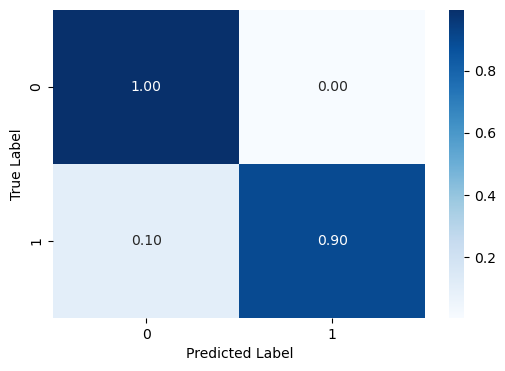

In [23]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb, normalize='true'), annot=True, fmt='.2f', cmap='Blues')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [24]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_xgb)
f1_scores = 2 * (precision * recall) / (precision + recall)
optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_idx]

print(f"Optimal threshold (based on test set): {optimal_threshold:.4f}")

# Predict labels for the test set based on the optimal threshold
y_pred_optimal_test = (y_pred_proba_xgb >= optimal_threshold).astype(int)

Optimal threshold (based on test set): 0.9998


In [25]:
# Generate and print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_optimal_test))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.76      0.79        98

    accuracy                           1.00     56962
   macro avg       0.91      0.88      0.89     56962
weighted avg       1.00      1.00      1.00     56962



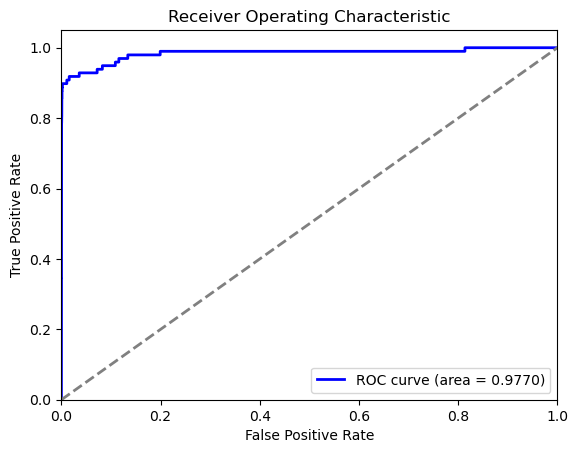

In [26]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

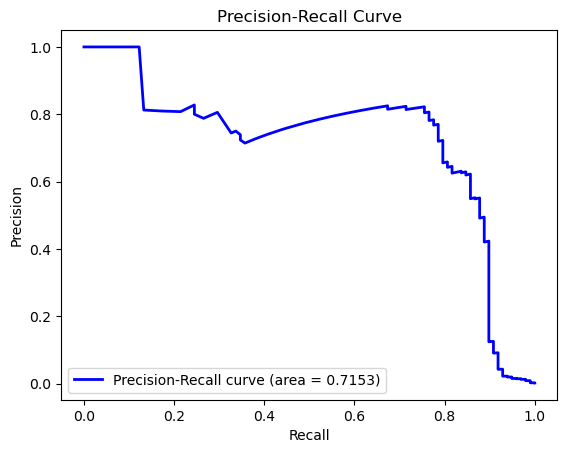

In [27]:
# Precision-Recall Curve 
precision_test, recall_test, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
 
plt.figure()
plt.plot(recall_test, precision_test, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc_rf:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

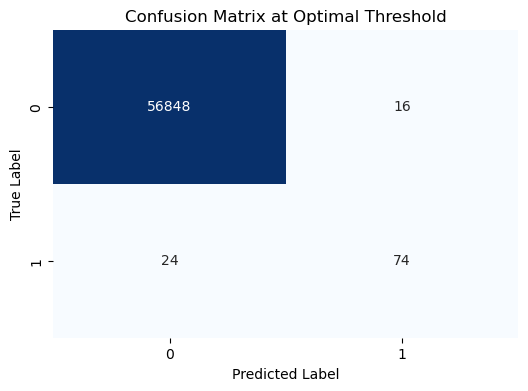

In [28]:
# Generate predictions based on the optimal threshold
y_pred_optimal_test = (y_pred_proba_xgb >= optimal_threshold).astype(int)

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred_optimal_test)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix at Optimal Threshold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()